In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.4
Plasticnet version  0.1.12
macOS-15.3.2-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
mu_c=0
sigma_c=0
mu_r=0
sigma_r=0



base_sim_dir=f"sims-2025-04-04 mu {mu_c} sigma {sigma_c}"
if not os.path.exists(base_sim_dir):
    os.mkdir(base_sim_dir)
print(base_sim_dir)

sims-2025-04-04 mu 0 sigma 0


In [4]:
number_of_neurons=20
eta=1e-6
number_of_processes=8
ray.init(num_cpus=number_of_processes)

2025-04-04 09:51:25,972	INFO worker.py:1841 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.43.0


(pid=79902) Splikes version  0.1.4
(pid=79902) Plasticnet version  0.1.12


In [5]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

In [6]:
def deficit(blur=[2.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day,
           save_interval=1*hour):

    
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=200*ms

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    rf_diameter=rf_size
    cpd=2**linspace(-4,3,10)
    deg_per_pixel=1/rf_diameter  # <=============
    k_mat=2*pi*cpd*deg_per_pixel

    
    sim+=pn.grating_response(print_time=False,
                        k_mat=k_mat,
                            )

    return sim,[pre,post],[c]


In [7]:
@ray.remote
def run_one_deficit_jitter(params,run=True,overwrite=False):
    import plasticnet as pn
    count,eta,noise,blur,mu_c,sigma_c,number_of_neurons,sfname=(params.count,params.eta,params.noise,
                        params.blur,params.mu_c,params.sigma_c,params.number_of_neurons,params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 blur=[blur,-1],
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 

    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    



In [26]:
func=func=run_one_deficit_jitter


blur_mat=[0,2,4,6,8,10,12]
open_eye_noise_mat=[0,.1,.2,.3,.4,.5]
mu_c_mat=[0,7,13,21]
sigma_c_mat=[0]
sigma_c=0


all_params=[]
for m,mu_c in enumerate(mu_c_mat):
    for b,blur in enumerate(blur_mat):
        for n,noise in enumerate(open_eye_noise_mat):
            sfname=base_sim_dir+f'/deficit {number_of_neurons} neurons noise {noise:.1f} blur {blur:0.1f} mu_c {mu_c:0.1f}.asdf'

            p=Struct()
            p.eta=eta
            p.number_of_neurons=number_of_neurons
            p.sfname=sfname

            p.noise=noise
            p.blur=blur
            p.mu_c=mu_c
            p.sigma_c=sigma_c

            all_params+=[p]

all_params=to_named_tuple(all_params)  


In [27]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)
    print(sfname)

100%|████████████████████████████████████████| 168/168 [00:00<00:00, 937.84it/s]

sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.1 blur 0.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.2 blur 0.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.3 blur 0.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.4 blur 0.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.5 blur 0.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 2.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.1 blur 2.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.2 blur 2.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.3 blur 2.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.4 blur 2.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.5 blur 2.0 mu_c 0.0.asdf
sims-2025-04-04 mu 0 sigma 0

In [10]:
do_params=make_do_params(all_params,verbose=True)

Doing 0 sims
Skipping 168 sims
[params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf', noise=0, blur=0, mu_c=0, sigma_c=0, count=0), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.1 blur 0.0 mu_c 0.0.asdf', noise=0.1, blur=0, mu_c=0, sigma_c=0, count=1), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.2 blur 0.0 mu_c 0.0.asdf', noise=0.2, blur=0, mu_c=0, sigma_c=0, count=2), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.3 blur 0.0 mu_c 0.0.asdf', noise=0.3, blur=0, mu_c=0, sigma_c=0, count=3), params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.4 blur 0.0 mu_c 0.0.asdf', noise=0.4, blur=0, mu_c=0, sigma_c=0, count=4)] ... [params(eta=1e-06, number_of_neurons=20, sfname='sims-2025-04-04 mu 0 s

In [11]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [12]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)

100%|█████████████████████████████████████████| 168/168 [00:25<00:00,  6.70it/s]


In [40]:
subResults={}
for params in tqdm(all_params):
    sfname=params.sfname
    R=RR[sfname]
    
    subR=Struct()
    subR.t=R.t/day
    t=subR.t
    
    subR.y=R.y
    subR.θ=R.θ

    #idx1,idx2=[_[1] for _ in R.sequence_index]
    
    subR.ODI=R.ODI
    subR.ORI=R.ORI
    subR.theta_mat=R.theta_mat
    subR.k_mat=R.k_mat
    subR.LSFV=R.LSFV
    subR.SF_Var=R.SF_Var
    subR.max_SF=R.max_SF
    subR.sfname=params.sfname
    subR.params=params
    subR.sequence_index=R.sequence_index
    subR.idx=[0]+[_[-1] for _ in R.sequence_index]
    subR.W=R.W[subR.idx,::]
    #subR.recovery_rate=(R.ODI[idx2,:]-R.ODI[idx1,:])/(t[idx2]-t[idx1])
    #subR.SF_Var_recovery_rate=(R.SF_Var[idx2,:]-R.SF_Var[idx1,:])/(t[idx2]-t[idx1])
    #subR.ODI2=R.ODI[idx2,:]
    #subR.ODI1=R.ODI[idx1,:]
    
    subResults[params.sfname]=subR

100%|████████████████████████████████████████| 168/168 [00:00<00:00, 326.23it/s]


In [41]:
# savevars(f'{base_sim_dir}/deficit_results.asdf',
#          'subResults','contrast_result','contrast_mat',
#           'contrast','recovery_rate_μ','recovery_rate_σ',
#             'ODI_μ1','ODI_σ1','ODI_μ2','ODI_σ2',
#           'SF_Var_recovery_rate_μ','SF_Var_recovery_rate_σ')

In [42]:
import plotutils

In [43]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'

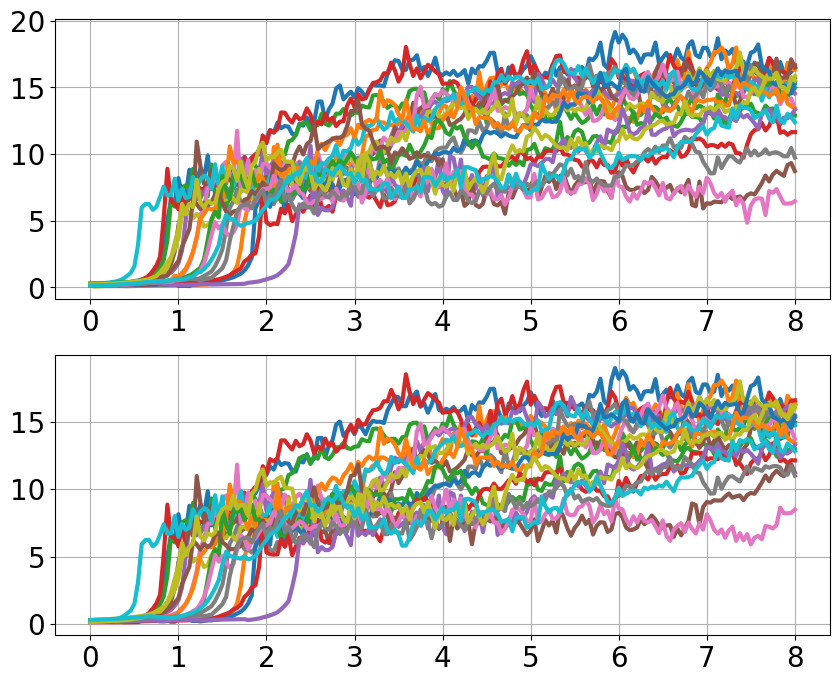

In [44]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'
subR=subResults[fname]
subplot(2,1,1)
plot(subR.t,subR.y[:,:,0]);

subplot(2,1,2)
plot(subR.t,subR.y[:,:,1]);


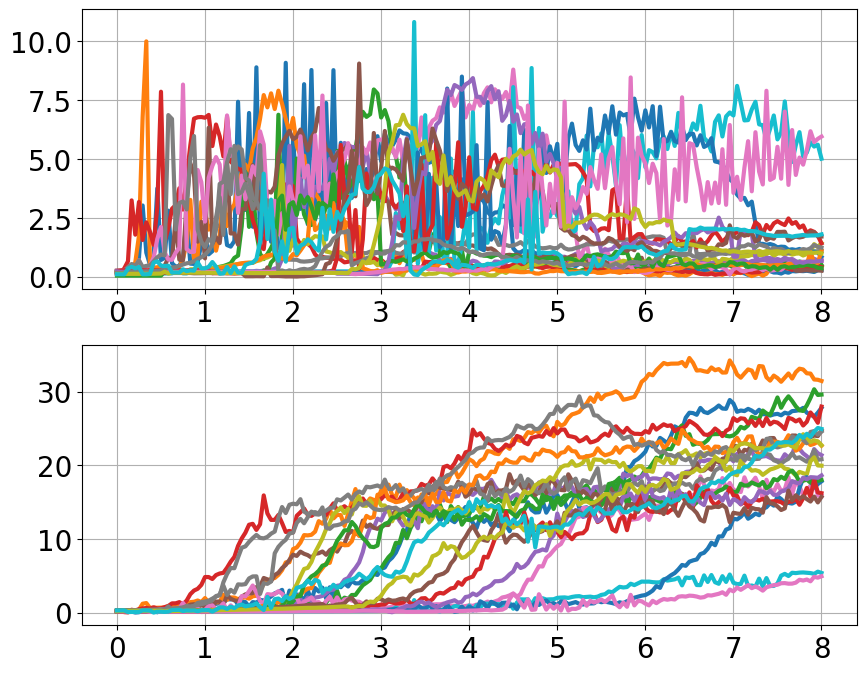

In [45]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 12.0 mu_c 0.0.asdf'
subR=subResults[fname]
subplot(2,1,1)
plot(subR.t,subR.y[:,:,0]);

subplot(2,1,2)
plot(subR.t,subR.y[:,:,1]);


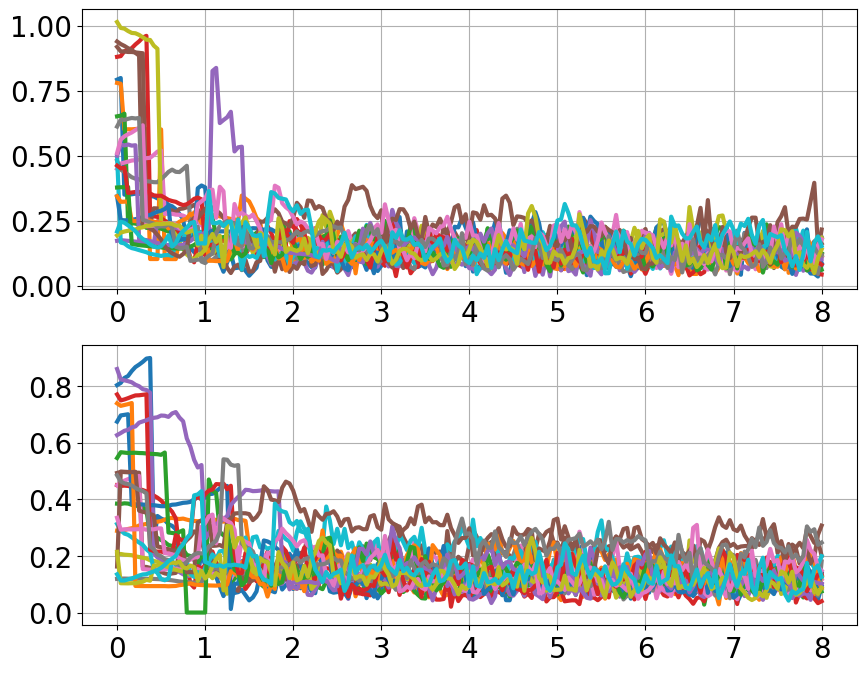

In [20]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'
subR=subResults[fname]
subplot(2,1,1)
plot(subR.t,subR.LSFV[:,:,0]);

subplot(2,1,2)
plot(subR.t,subR.LSFV[:,:,1]);


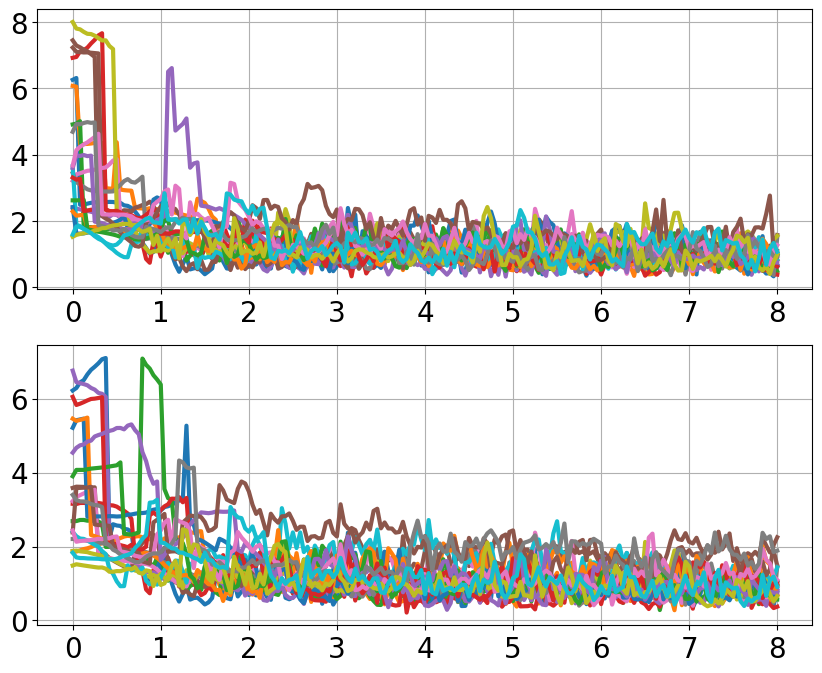

In [46]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'
subR=subResults[fname]
subplot(2,1,1)
plot(subR.t,subR.SF_Var[:,:,0]);

subplot(2,1,2)
plot(subR.t,subR.SF_Var[:,:,1]);


entropy measure?

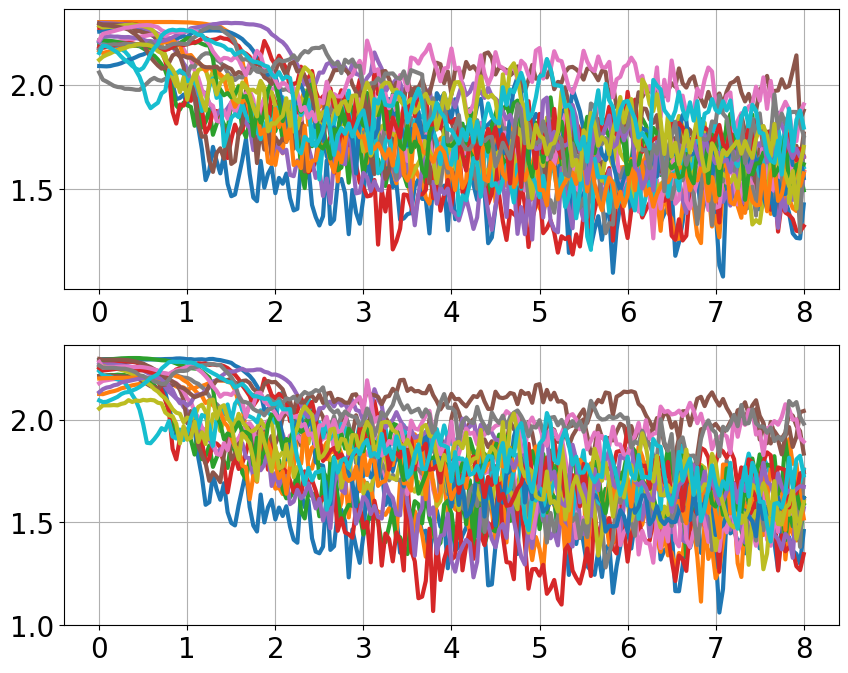

In [97]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0.asdf'
subR=subResults[fname]

_self=RR[fname]
tt=[]
LL=[]
for response in _self.all_responses:
    t,y=response    # k, theta, channel, neuron, time
    y=y.max(axis=1)  # optimize over theta
    rk=y.transpose([1,2,3,0])
    norm_rk=rk.sum(axis=3)
    norm_rk=expand_dims(norm_rk,3)
    rk/=norm_rk

    L=-(rk*log(rk)).sum(axis=3)
    
    tt.append(t)
    L=L.transpose([2,1,0])  # want it to be time, neurons, channel
    LL.append(L)

t=hstack(tt)
kk=concatenate(LL,axis=0)        




subplot(2,1,1)
plot(subR.t,kk[:,:,0]);

subplot(2,1,2)
plot(subR.t,kk[:,:,1]);


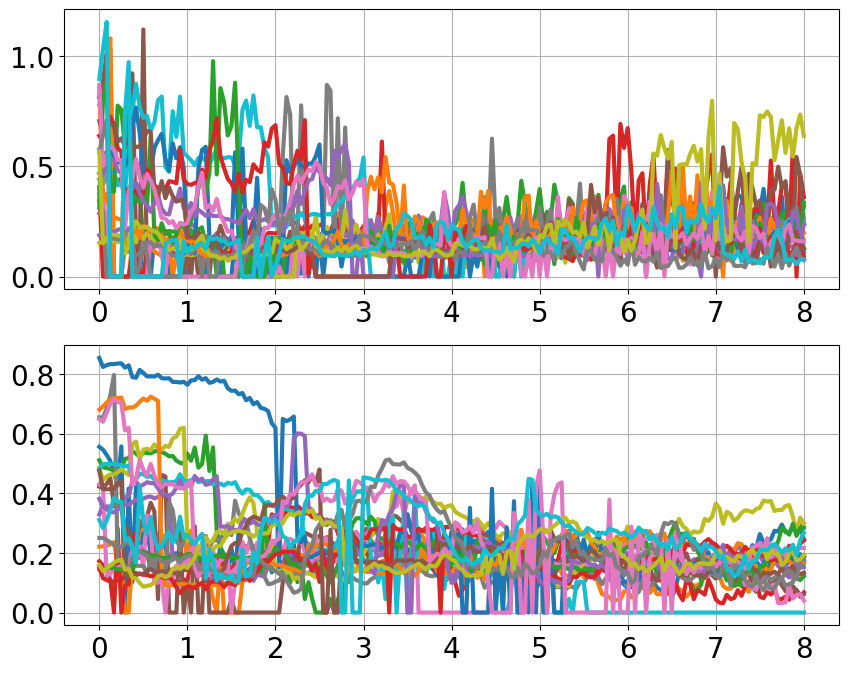

In [99]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 12.0 mu_c 0.0.asdf'
subR=subResults[fname]
subplot(2,1,1)
plot(subR.t,subR.LSFV[:,:,0]);

subplot(2,1,2)
plot(subR.t,subR.LSFV[:,:,1]);


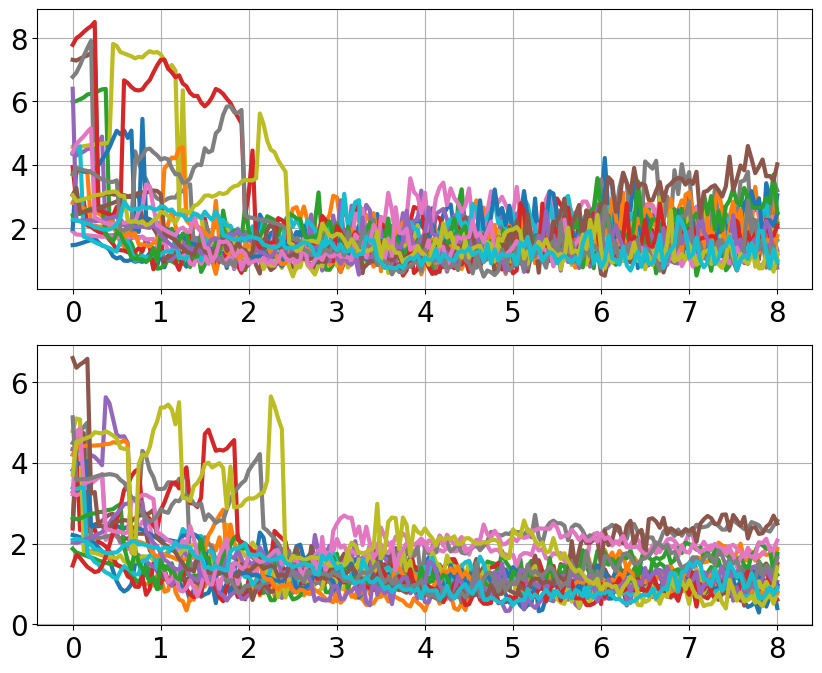

In [124]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 2.0 mu_c 0.0.asdf'
subR=subResults[fname]
subplot(2,1,1)
plot(subR.t,subR.SF_Var[:,:,0]);

subplot(2,1,2)
plot(subR.t,subR.SF_Var[:,:,1]);


In [125]:
def calc_μσ(arr):
    # time, neurons, channel
    μ=arr.mean(axis=1)  # average across neurons
    S=arr.std(axis=1)  #  across neurons
    N=arr.shape[1]
    K=1+20/N**2
    σ=K*S/np.sqrt(N)

    return μ,σ

In [126]:
μ,σ=calc_μσ(subR.y)
μ.shape

(193, 2)

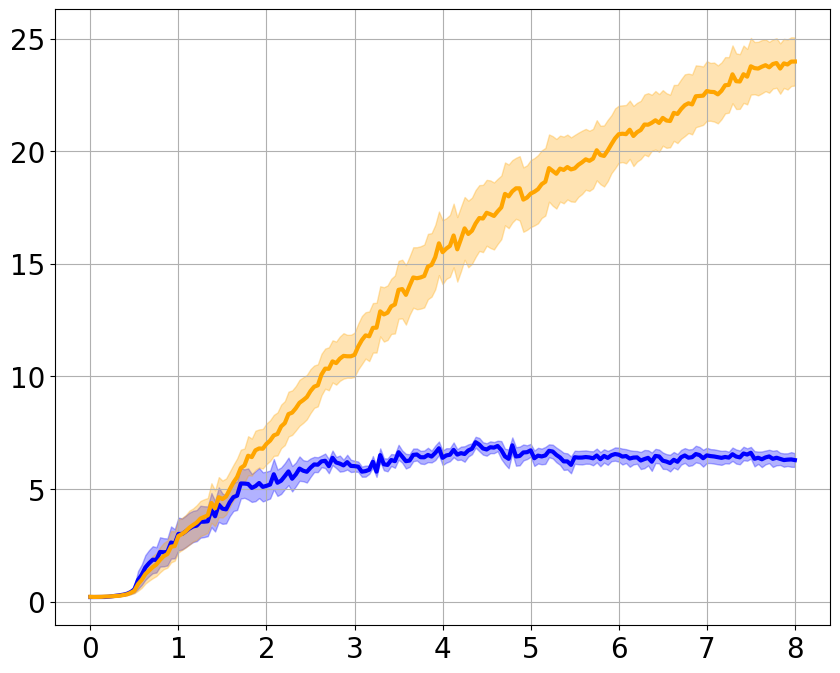

In [127]:
plot(subR.t,μ[:,0],color='blue')
fill_between(subR.t, 
             μ[:,0] - σ[:,0], 
             μ[:,0] + σ[:,0], 
             color='blue', alpha=0.3, label='Uncertainty')



plot(subR.t,μ[:,1],color='orange')
fill_between(subR.t, 
             μ[:,1] - σ[:,1], 
             μ[:,1] + σ[:,1], 
             color='orange', alpha=0.3, label='Uncertainty')

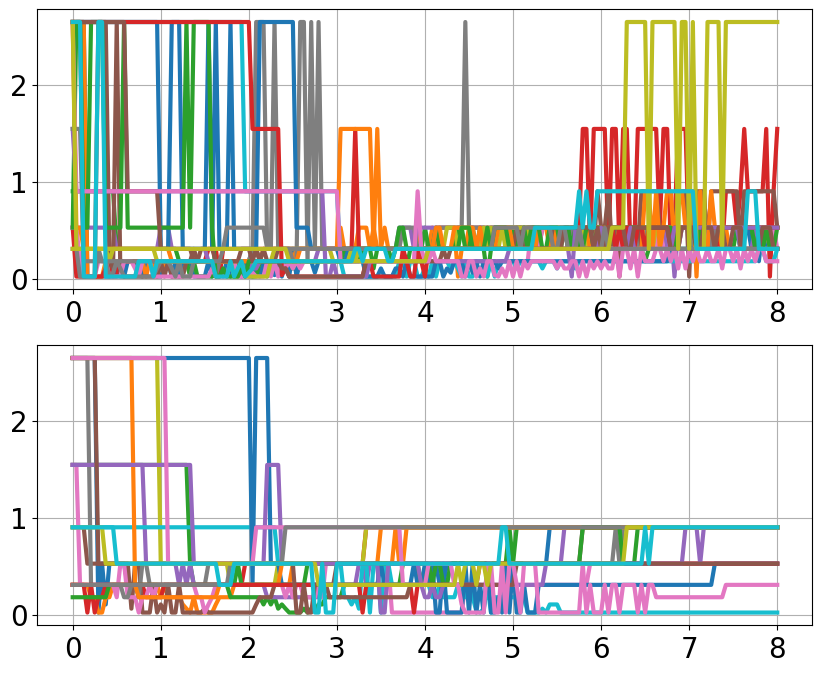

In [49]:
fname='sims-2025-04-04 mu 0 sigma 0/deficit 20 neurons noise 0.0 blur 12.0 mu_c 0.0.asdf'
subR=subResults[fname]
subplot(2,1,1)
plot(subR.t,subR.max_SF[:,:,0]);

subplot(2,1,2)
plot(subR.t,subR.max_SF[:,:,1]);


In [23]:
μ,σ=μσ(subR.LSFV,axis=1)
μ.shape

(193, 2)

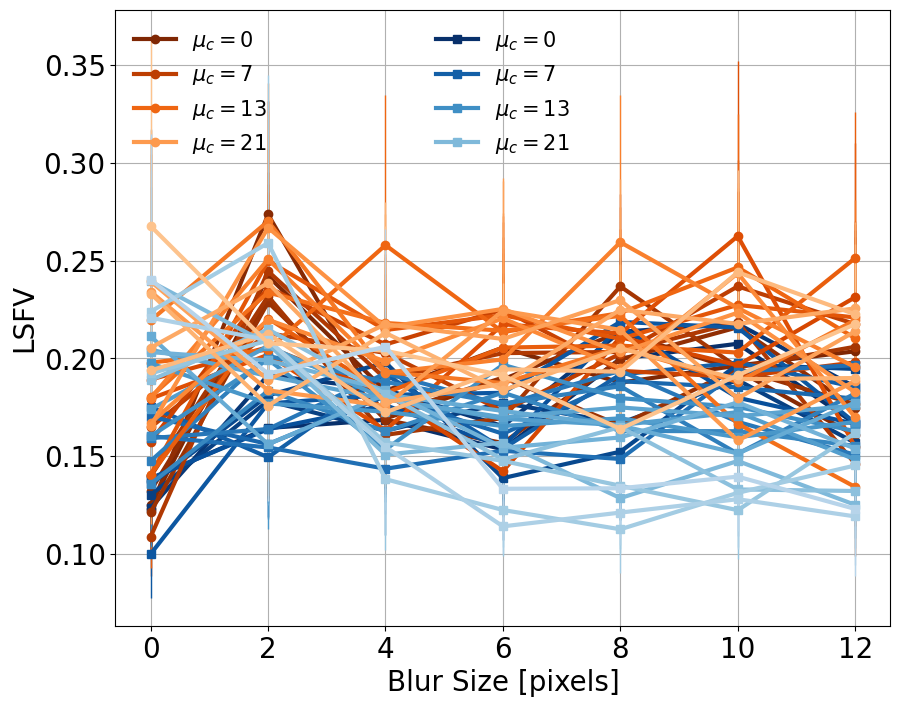

In [50]:
n = 10

colormap=cm.tab10
color = colormap(np.linspace(0, 1,n))


v=np.flip(linspace(0.3,1,len(mu_c_mat)*len(open_eye_noise_mat)))

color_count=0
count=0
h1=[]
h2=[]
labels=[]

sigma_c=0

for m,mu_c in enumerate(mu_c_mat):
    labels+=[f'$\\mu_c={mu_c}$']

    for n,noise in enumerate(open_eye_noise_mat):
    
        St=Storage()
    
        for b,blur in enumerate(blur_mat):
            sfname=base_sim_dir+f'/deficit {number_of_neurons} neurons noise {noise:.1f} blur {blur:0.1f} mu_c {mu_c:0.1f}.asdf'

            subR=subResults[sfname]
            μ,σ=μσ(subR.LSFV,axis=1)

            St+=blur,μ[-1,0],μ[-1,1],σ[-1,0],σ[-1,1]

        blur,μ1,μ2,σ1,σ2=St.arrays()
        
        h=errorbar(blur,μ1,yerr=2*σ1,marker='o',elinewidth=1,color=cm.Oranges(v[color_count]))
        if n==0:
            h1+=[h[0]]
        h=errorbar(blur,μ2,yerr=2*σ2,marker='s',elinewidth=1,color=cm.Blues(v[color_count]))
        if n==0:
            h2+=[h[0]]
        xlabel('Blur Size [pixels]')
        ylabel('LSFV')
    
        color_count+=1

# specify the lines and labels of the first legend
ax=gca()
ax.legend(h1, labels,
          loc='upper left', frameon=False,fontsize=15)

#text(0,5,'Amblyopic',color=cm.Oranges(v[1]))

# # Create the second legend and add the artist manually.
from matplotlib.legend import Legend
leg = Legend(ax, h2, labels,
              loc='upper center', frameon=False,fontsize=15)
ax.add_artist(leg)
#text(7,40,'Fellow',color=cm.Blues(v[1]))



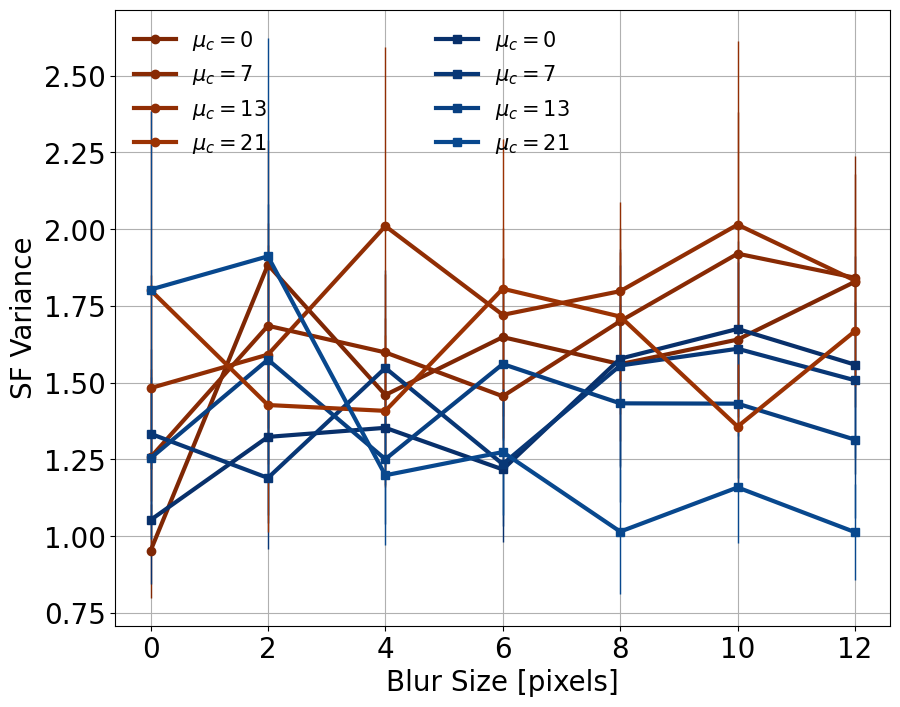

In [52]:
n = 10

colormap=cm.tab10
color = colormap(np.linspace(0, 1,n))


v=np.flip(linspace(0.3,1,len(mu_c_mat)*len(open_eye_noise_mat)))

color_count=0
count=0
h1=[]
h2=[]
labels=[]

sigma_c=0

for m,mu_c in enumerate(mu_c_mat):
    labels+=[f'$\\mu_c={mu_c}$']

    for n,noise in enumerate(open_eye_noise_mat[:1]):
    
        St=Storage()
    
        for b,blur in enumerate(blur_mat):
            sfname=base_sim_dir+f'/deficit {number_of_neurons} neurons noise {noise:.1f} blur {blur:0.1f} mu_c {mu_c:0.1f}.asdf'

            subR=subResults[sfname]
            μ,σ=μσ(subR.SF_Var,axis=1)

            St+=blur,μ[-1,0],μ[-1,1],σ[-1,0],σ[-1,1]

        blur,μ1,μ2,σ1,σ2=St.arrays()
        
        h=errorbar(blur,μ1,yerr=2*σ1,marker='o',elinewidth=1,color=cm.Oranges(v[color_count]))
        if n==0:
            h1+=[h[0]]
        h=errorbar(blur,μ2,yerr=2*σ2,marker='s',elinewidth=1,color=cm.Blues(v[color_count]))
        if n==0:
            h2+=[h[0]]
        xlabel('Blur Size [pixels]')
        ylabel('SF Variance')
    
        color_count+=1

# specify the lines and labels of the first legend
ax=gca()
ax.legend(h1, labels,
          loc='upper left', frameon=False,fontsize=15)

#text(0,5,'Amblyopic',color=cm.Oranges(v[1]))

# # Create the second legend and add the artist manually.
from matplotlib.legend import Legend
leg = Legend(ax, h2, labels,
              loc='upper center', frameon=False,fontsize=15)
ax.add_artist(leg)
#text(7,40,'Fellow',color=cm.Blues(v[1]))



Text(7, 20, 'Fellow')

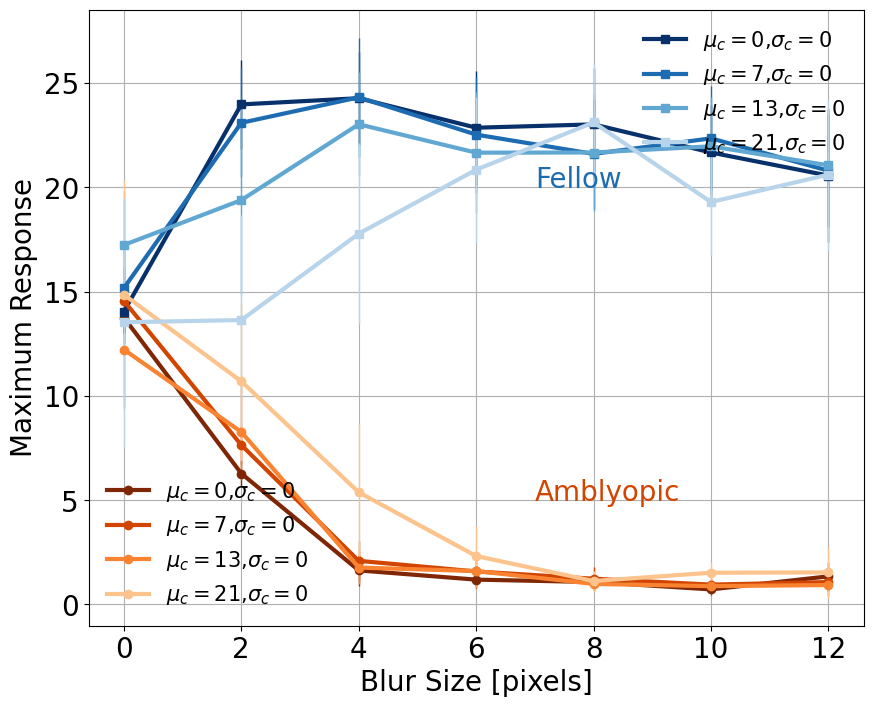

In [39]:
n = 10

colormap=cm.tab10
color = colormap(np.linspace(0, 1,n))


v=np.flip(linspace(0.3,1,4))

color_count=0
count=0
h1=[]
h2=[]
labels=[]
for mu_count,mu_c in enumerate(mu_c_mat):
    for sigma_count,sigma_c in enumerate(sigma_c_mat):
        
        labels+=[f'$\\mu_c={mu_c}$,$\\sigma_c={sigma_c}$']
        
        _s=Storage()
        for blur_count,blur in enumerate(blur_mat):


            params=all_params[count]
            count+=len(open_eye_noise_mat)

            R=RR[params.sfname]

            assert blur==params.blur 
            blur=params.blur
            
            μ1,μ2=R.μσ[0][0]
            σ1,σ2=R.μσ[1][0]

            _s+=blur,μ1,μ2,σ1,σ2

        blur,μ1,μ2,σ1,σ2=_s.arrays()
        h=errorbar(blur,μ1,yerr=2*σ1,marker='o',elinewidth=1,color=cm.Oranges(v[color_count]))
        h1+=[h[0]]
        h=errorbar(blur,μ2,yerr=2*σ2,marker='s',elinewidth=1,color=cm.Blues(v[color_count]))
        h2+=[h[0]]
        xlabel('Blur Size [pixels]')
        ylabel('Maximum Response')
        
        color_count+=1


# specify the lines and labels of the first legend
ax=gca()
ax.legend(h1, labels,
          loc='lower left', frameon=False,fontsize=15)

text(7,5,'Amblyopic',color=cm.Oranges(v[1]))

# # Create the second legend and add the artist manually.
from matplotlib.legend import Legend
leg = Legend(ax, h2, labels,
              loc='upper right', frameon=False,fontsize=15)
ax.add_artist(leg)
text(7,20,'Fellow',color=cm.Blues(v[1]))



In [37]:
blur_mat

[0, 2, 4, 6, 8, 10, 12]